In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn

from dpks import QuantMatrix
from dfmodel import DigitalFamilyBinary
from scanpy.experimental.pp import highly_variable_genes


In [2]:
def preprocess_data(raw_data, design_matrix):

    quant_matrix = QuantMatrix(
        quantification_file=raw_data[['Protein'] + [sample for sample in design_matrix['sample'].values]].copy(),
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
    )

    quant_data = quant_matrix.to_df()

    quant_data = quant_data[~((quant_data["ProteinLabel"].str.startswith("HV")) | (quant_data["ProteinLabel"].str.startswith("LV")) | quant_data["ProteinLabel"].str.startswith("KV"))]
    quant_data = quant_data[~quant_data["ProteinLabel"].str.startswith("IG")]
    quant_data = quant_data[~((quant_data["ProteinLabel"] == "HBA_HUMAN") | (quant_data["ProteinLabel"] == "HBB_HUMAN") | (quant_data["ProteinLabel"] == "HBD_HUMAN") | (quant_data["ProteinLabel"] == "HEMO_HUMAN"))]

    quant_matrix = QuantMatrix(
        quantification_file=quant_data,
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
    )

    return quant_matrix

In [3]:
proteomics_data_train = pd.read_csv(
    "../0_data/proteins_train_filtered.tsv"
    , sep="\t"
)
clinical_data_train = pd.read_csv(
    "../0_data/design_matrix_train.tsv",
    sep='\t'
)
clinical_data_train['sample'] = clinical_data_train['injection']

In [4]:
#clinical_data_train = clinical_data_train[clinical_data_train['sepsis_or_septic_shock'] == 1.0]

In [5]:
quant_matrix_train = preprocess_data(proteomics_data_train, design_matrix=clinical_data_train)

In [7]:
X, y = quant_matrix_train.to_ml(feature_column="ProteinLabel", label_column="sepsis_or_septic_shock", comparison=(0, 1))


In [8]:
quant_matrix_train.quantitative_data.var

,Unnamed: 0,injection,sao2_ambulance,resp_frequency_ambulance,heart_rate_ambulance,syst_bp_ambulance,map_ambulance,mental_status_ambulance,temperature_ambulance,crea_emergency_department,...,sofa_coag_day1,sofa_coag_day2,sofa_coag_day3,sofa_cns_day1,sofa_cns_day2,sofa_cns_day3,sofa_liver_day1,sofa_liver_day2,sofa_liver_day3,sample
sample,,,,,,,,,,,,,,,,,,,,,
SA_BOX_1-462_S1-C8_1_6848,0,SA_BOX_1-462_S1-C8_1_6848,85.0,24.0,120.0,120.0,95.333333,1.0,39.5,73.0,...,1.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,SA_BOX_1-462_S1-C8_1_6848
SA_BOX_9-2606_S1-A5_1_6136,1,SA_BOX_9-2606_S1-A5_1_6136,75.0,30.0,117.0,134.0,107.333333,1.0,37.3,121.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,SA_BOX_9-2606_S1-A5_1_6136
SA_BOX_3-2442_S4-H8_1_5579,2,SA_BOX_3-2442_S4-H8_1_5579,94.0,48.0,125.0,120.0,NaN,1.0,39.9,66.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,SA_BOX_3-2442_S4-H8_1_5579
SA_BOX_2-1644_S2-A10_1_6960,3,SA_BOX_2-1644_S2-A10_1_6960,80.0,35.0,94.0,113.0,75.666667,1.0,38.6,122.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,SA_BOX_2-1644_S2-A10_1_6960
SA_BOX_4-2435_S5-E11_1_5698,4,SA_BOX_4-2435_S5-E11_1_5698,87.0,18.0,75.0,136.0,121.333333,1.0,35.6,107.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,SA_BOX_4-2435_S5-E11_1_5698
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SA_BOX_11-2056_S4-F8_1_6362,675,SA_BOX_11-2056_S4-F8_1_6362,96.0,40.0,95.0,110.0,80.000000,1.0,37.5,92.0,...,0.0,0.0,NaN,0.0,NaN,NaN,0.0,0.0,NaN,SA_BOX_11-2056_S4-F8_1_6362
SA_BOX_3-697_S4-A6_1_5555,676,SA_BOX_3-697_S4-A6_1_5555,90.0,30.0,102.0,140.0,106.666667,1.0,39.0,62.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,SA_BOX_3-697_S4-A6_1_5555
SA_BOX_8-2367_S5-C12_1_6096,677,SA_BOX_8-2367_S5-C12_1_6096,74.0,40.0,100.0,133.0,97.666667,1.0,37.4,71.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,SA_BOX_8-2367_S5-C12_1_6096


In [9]:
X = X.loc[:, X.var() > X.var().median()]
protein_columns = X.columns.to_list()

In [10]:
clinical_columns = [
    "sao2_ambulance",
    "resp_frequency_ambulance",
    "heart_rate_ambulance",
    "syst_bp_ambulance",
    "map_ambulance",
    "mental_status_ambulance",
    "temperature_ambulance",
    "crea_emergency_department",
    "bili_emergency_department",
    "crp_day1",
    "trc_emergency_department",
    "sex",
    "age",
]

continuous_clinical_columns = [
    "sao2_ambulance",
    "resp_frequency_ambulance",
    "heart_rate_ambulance",
    "syst_bp_ambulance",
    "map_ambulance",
    "temperature_ambulance",
    "crea_emergency_department",
    "bili_emergency_department",
    "trc_emergency_department",
    "crp_day1",
    "age",
    #"mental_status_ambulance",
]

categorical_clinical_columns = [
    "mental_status_ambulance",
]

In [11]:
from sklearn.preprocessing import StandardScaler

protein_scaler = StandardScaler()
X[protein_columns] = protein_scaler.fit_transform(X[protein_columns])

In [12]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler

clinical_scaler = StandardScaler()

clinical_imputer = SimpleImputer()
sex_scaler = MinMaxScaler((0, 1))
constant_imputer = SimpleImputer(strategy="constant", fill_value=1.0)

clinical_data_train[continuous_clinical_columns] = clinical_imputer.fit_transform(clinical_data_train[continuous_clinical_columns])
clinical_data_train[["mental_status_ambulance"]] = constant_imputer.fit_transform(clinical_data_train[["mental_status_ambulance"]])

clinical_data_train[continuous_clinical_columns] = clinical_scaler.fit_transform(clinical_data_train[continuous_clinical_columns])
clinical_data_train[['sex']] = sex_scaler.fit_transform(clinical_data_train[['sex']])


In [37]:
clinical_data_train['resp_dysfunction'] =  np.where(
    clinical_data_train['sofa_resp_day2'] > 1, 1, np.where(
        clinical_data_train['sofa_resp_day3'] > 1, 1, 0
    )
)

clinical_data_train['renal_dysfunction'] = np.where(
    clinical_data_train['sofa_renal_day2'] > 0, 1, np.where(
        clinical_data_train['sofa_renal_day2'] > 0, 1, 0
    )
)

clinical_data_train['cardiovasc_dysfunction'] = np.where(
    clinical_data_train['sofa_cardiovasc_day2'] > 0, 1, np.where(
        clinical_data_train['sofa_cardiovasc_day3'] > 0, 1, 0
    )
)

clinical_data_train['coag_dysfunction'] = np.where(
    clinical_data_train['sofa_coag_day2'] > 0, 1, np.where(
        clinical_data_train['sofa_coag_day3'] > 0, 1, 0
    )
)

clinical_data_train['cns_dysfunction'] = np.where(
    clinical_data_train['sofa_cns_day2'] > 0, 1, np.where(
        clinical_data_train['sofa_cns_day3'] > 0, 1, 0
    )
)

clinical_data_train['liver_dysfunction'] = np.where(
    clinical_data_train['sofa_liver_day2'] > 0, 1, np.where(
        clinical_data_train['sofa_liver_day3'] > 0, 1, 0
    )
)

In [38]:
import anndata as ad

clinical_adata = ad.AnnData(
    X=clinical_data_train.set_index("injection")[clinical_columns],
    obs=clinical_data_train.set_index("injection")
)

protein_adata = ad.AnnData(
    X=X[protein_columns],
    obs=quant_matrix_train.quantitative_data.var.set_index("sample")
)

In [39]:
import muon as mu

mdata = mu.MuData(
    {
        "proteomics": protein_adata,
        "clinical": clinical_adata,
    }
)

In [54]:
mu.tl.mofa(
    mdata,
    outfile="clinprot_model",
    use_var="highly_variable",
    n_factors=10
)


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
       
 
        
Loaded view='proteomics' group='group1' with N=680 samples and D=143 features...
Loaded view='clinical' group='group1' with N=680 samples and D=13 features...


Model options:
- Automatic Relevance Determination prior on the factors: True
- Automatic Relevance Determination prior on the weights: True
- Spike-and-slab prior on the factors: False
- Spike-and-slab prior on the weig

In [55]:
mofa_columns = []

for i in range(mdata.obsm['X_mofa'].shape[1]):

    clinical_data_train[f"MOFA {i}"] = mdata.obsm['X_mofa'][:, i]

    mofa_columns.append(f"MOFA {i}")



In [56]:
mdata.obsm['X_mofa']

array([[-3.50100590e+00, -1.64194715e-01,  6.42100532e-01, ...,
         3.19549769e+00,  3.21728748e-01,  1.44884605e-29],
       [-1.80284958e-01,  3.87689233e-01, -6.64898651e-01, ...,
        -5.03015343e-01, -1.89770250e+00,  1.18624251e-29],
       [ 1.08678133e-01,  1.21989050e-01,  1.19434548e+00, ...,
        -1.96113025e+00, -4.84364622e-01,  1.72144487e-28],
       ...,
       [ 1.52792060e+00,  4.28921455e-01,  1.20560657e+00, ...,
         1.07538502e+00,  3.51008979e+00,  1.58754842e-28],
       [-2.80477957e-01, -5.06804840e-01,  4.36949484e-01, ...,
         4.66638220e+00,  2.59914778e+00,  3.76160504e-28],
       [ 1.20127080e+00, -8.91410562e-01, -1.25546974e+00, ...,
        -2.56098238e+00, -2.12555183e-01, -3.90212319e-30]])

In [57]:
import mofax as mofa

In [60]:
model = mofa.mofa_model("clinprot_model")
model

MOFA+ model: clinprot model
Samples (cells): 680
Features: 156
Groups: group1 (680)
Views: clinical (13), proteomics (143)
Factors: 10
Expectations: W, Z

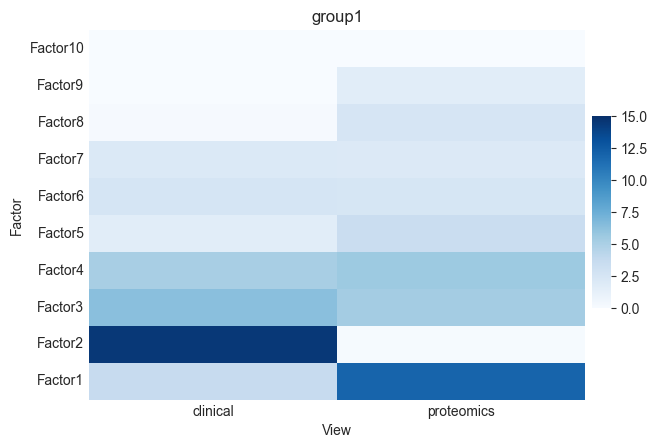

In [61]:
mofa.plot_r2(model, x='View', vmax=15)

<Axes: title={'center': 'clinical'}, xlabel='Feature weight'>

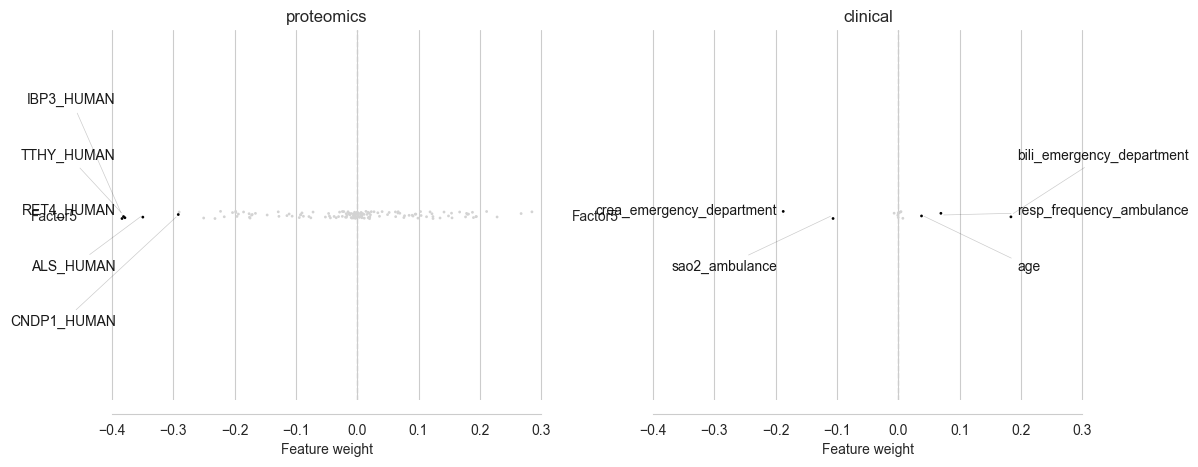

In [62]:
mofa.plot_weights(model, views=['proteomics', 'clinical'], factors=4, zero_line=True, ncols=2, label_size=10)

In [63]:
model.get_r2()

,Factor,View,Group,R2
0,Factor1,proteomics,group1,11.962039
1,Factor1,clinical,group1,3.708064
2,Factor2,proteomics,group1,0.117384
3,Factor2,clinical,group1,14.482503
4,Factor3,proteomics,group1,5.353436
5,Factor3,clinical,group1,6.340991
6,Factor4,proteomics,group1,5.635103
7,Factor4,clinical,group1,5.159266
8,Factor5,proteomics,group1,3.472157
9,Factor5,clinical,group1,1.660243


In [64]:
model.get_weights(
    #views=["proteomics"],
   #factors=[1],
    df=True
).sort_values("Factor1", ascending=False).head(30)

,Factor1,Factor2,Factor3,Factor4,Factor5,Factor6,Factor7,Factor8,Factor9,Factor10
CFAD_HUMAN,0.360807,-0.008948,-0.076066,0.255978,-0.203419,-0.101113,-0.000225,0.000175,-0.000057,-1.576404e-30
LYSC_HUMAN,0.353326,0.000214,-0.069000,0.195980,-0.090047,-0.060146,0.008410,-0.000110,0.000092,1.624655e-29
B2MG_HUMAN,0.333416,-0.007604,0.000292,0.349376,-0.092234,-0.086143,-0.123225,-0.003741,0.000024,-1.465286e-29
TPM4_HUMAN,0.333309,-0.021236,0.000182,-0.384841,0.007347,-0.036360,-0.002324,-0.206281,0.000101,-1.241857e-29
PTGDS_HUMAN,0.327353,-0.001788,-0.133119,0.256219,-0.222962,-0.113327,0.070073,-0.005120,-0.000035,-2.706397e-30
ACTB_HUMAN,0.322272,-0.006943,0.059765,-0.294348,0.123668,0.076191,-0.031943,-0.132745,-0.000019,-2.958869e-29
TPM3_HUMAN,0.321577,-0.011621,0.004068,-0.293405,0.095594,-0.013257,-0.013924,0.001176,0.000283,-9.577064e-30
COIA1_HUMAN,0.301172,0.045821,-0.072406,0.210059,-0.166010,-0.154438,-0.094903,0.006567,0.000859,1.042839e-29
IBP2_HUMAN,0.285741,-0.004355,-0.000963,0.183406,0.001758,-0.104317,-0.091651,-0.016359,0.001288,3.773470e-29
1433Z_HUMAN,0.285053,-0.060949,0.034314,-0.164980,0.167071,0.015227,-0.018312,0.074062,-0.000002,-2.167902e-29


In [65]:
model.close()

In [66]:

X_mofa = mdata.obsm['X_mofa']

In [67]:
mofa_columns = []

for i in range(X_mofa.shape[1]):

    mofa_col = f"MOFA {i}"

    mofa_columns.append(mofa_col)

    clinical_data_train[mofa_col] = X_mofa[:, i]

In [68]:
df_estimator = DigitalFamilyBinary(n_neighbors=10, neighbor_metric="euclidean")

In [69]:
df_estimator.fit(clinical_data_train, features=mofa_columns)

In [70]:
clinical_data_train['Resp Rate'] = df_estimator.predict(clinical_data_train, features=mofa_columns, target_column="resp_dysfunction", bootstrap=False)

clinical_data_train['Renal Rate'] = df_estimator.predict(clinical_data_train, features=mofa_columns, target_column="renal_dysfunction", bootstrap=False)

clinical_data_train['Cardio Rate'] = df_estimator.predict(clinical_data_train, features=mofa_columns, target_column="cardiovasc_dysfunction", bootstrap=False)

clinical_data_train['Liver Rate'] = df_estimator.predict(clinical_data_train, features=mofa_columns, target_column="liver_dysfunction", bootstrap=False)

clinical_data_train['CNS Rate'] = df_estimator.predict(clinical_data_train, features=mofa_columns, target_column="cns_dysfunction", bootstrap=False)

clinical_data_train['Coag Rate'] = df_estimator.predict(clinical_data_train, features=mofa_columns, target_column="coag_dysfunction", bootstrap=False)

In [71]:
display_columns = [
    "Resp Rate",
    "Renal Rate",
    "Cardio Rate",
    "Liver Rate",
    "CNS Rate",
    "Coag Rate",
]

In [72]:
import matplotlib.pyplot as plt
import networkx as nx

G = df_estimator.network_


positions = nx.forceatlas2_layout(
    G,
    max_iter=1000,
    seed=0,
    #strong_gravity=True,
    dissuade_hubs=True
)

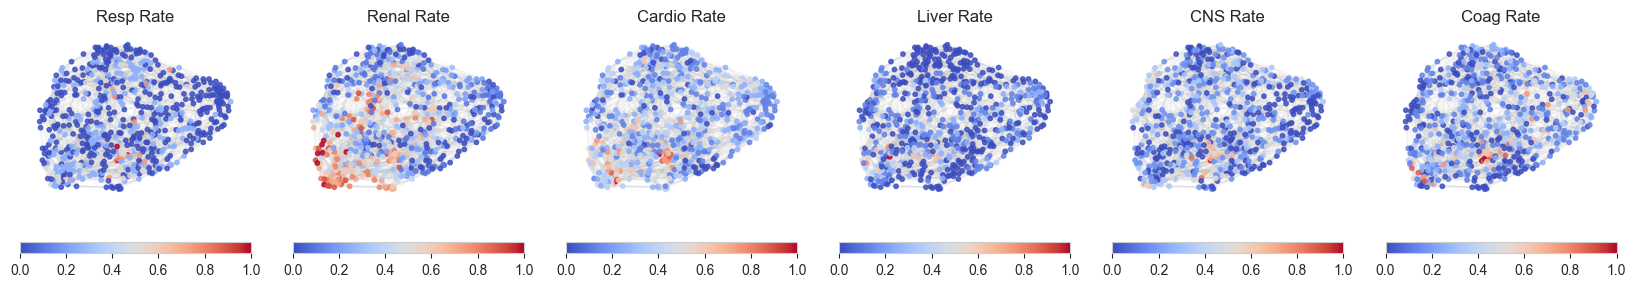

In [34]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(
    nrows=1,
    ncols=6
)

for i, col in enumerate(display_columns):

    # values = training_data[col].to_numpy()
    # cmap = plt.cm.coolwarm
    # norm = plt.Normalize(vmin=training_data[col].min(), vmax=training_data[col].max())
    # colors = cmap(norm(values))

    color_normalizer = MinMaxScaler((0, 1))

    values = MinMaxScaler().fit_transform(clinical_data_train[[col]])

    color_map = dict(zip(clinical_data_train.index, values))
    node_colors = [color_map[node] for node in G.nodes()]

    nx.draw_networkx_nodes(G, positions, node_size=10, node_color=node_colors, cmap="coolwarm", alpha=0.8, ax=axs[i])
    nx.draw_networkx_edges(G, positions, edge_color="gray", alpha=0.05, ax=axs[i])

    axs[i].axis("off")

    axs[i].set_title(col)

    sm = plt.cm.ScalarMappable(cmap="coolwarm")
    cbar = fig.colorbar(sm, ax=axs[i], orientation="horizontal")

    #cbar = fig.colorbar(ax=axs[i])

fig.set_size_inches((8.27 * 2, 3))
plt.tight_layout()

<Axes: >

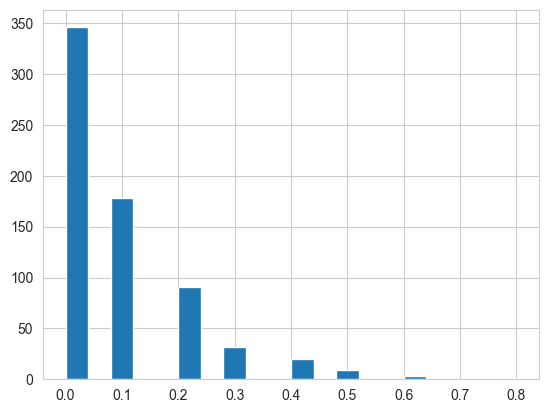

In [35]:
clinical_data_train['Liver Rate'].hist(bins=20)

In [36]:
clinical_data_train.to_csv(
    "organ_dysfunction_design_matrix.tsv",
    sep="\t",
    index=False
)